# Finding Blob analogs

In [8]:
import json
import numpy as np

thresholds = np.arange(0.1, 0.81, 0.1)  # index 4 = 0.5

with open('object_id_ls_greenmask_linearr2.json', 'r') as f:
    old_linear = json.load(f)

with open('object_id_ls_greenmask_linear_corrected.json', 'r') as f:
    new_linear = json.load(f)

old_counts_linear = [sum(len(m) for m in threshold_data) for threshold_data in old_linear]
new_counts_linear = [sum(len(m) for m in threshold_data) for threshold_data in new_linear]

print("Original linear counts:        ", old_counts_linear)
print("Current session linear counts: ", new_counts_linear)

match = old_counts_linear == new_counts_linear
print("Exact match:", match)

if not match:
    diffs = [(t, o, c) for t, o, c in zip(thresholds, old_counts_linear, new_counts_linear) if o != c]
    print("Differences (threshold, old, new):", diffs)

Original linear counts:         [4382, 2466, 1387, 775, 407, 202, 93, 19]
Current session linear counts:  [3652, 1735, 919, 561, 331, 184, 90, 19]
Exact match: False
Differences (threshold, old, new): [(0.1, 4382, 3652), (0.2, 2466, 1735), (0.30000000000000004, 1387, 919), (0.4, 775, 561), (0.5, 407, 331), (0.6, 202, 184), (0.7000000000000001, 93, 90)]


In [9]:
import xarray as xr

mhwobj_paths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_check = xr.open_mfdataset(mhwobj_paths, combine='nested', concat_dim='ensemble_member')

# Check the FULL time range in the raw file, before any .sel(time=slice(...)) is applied
print("Full time range in raw file:", da_check.labels.time.min().values, da_check.labels.time.max().values)
print("Total number of timesteps:", da_check.labels.sizes['time'])

Full time range in raw file: 1979-01-01 00:00:00 2022-12-01 00:00:00
Total number of timesteps: 528


## 0. Set up

### 0.0 Import packages

In [1]:
import cmocean
import numpy as np
import xarray as xr
import pandas as pd
import cftime
import dask
import matplotlib.pyplot as plt
import os
import xesmf as xe
import pop_tools
import json
import re
from scipy import stats
from scipy.ndimage import uniform_filter1d

import bottleneck

import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter,LatitudeFormatter
from cartopy.util import add_cyclic_point
from matplotlib.colors import Normalize
from matplotlib.colors import LogNorm  # <-- Add this import
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import matplotlib.dates as mdates
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import FFMpegWriter as fw
from matplotlib.animation import PillowWriter as pw

from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy.stats import gaussian_kde
import imageio

from IPython.utils import io
from os.path import exists

import dask
import dask_jobqueue
import distributed
import dask.array as da

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

### Fill out Supplemental Table 3. Sensitivity analysis of MHW identification in the North Pacific Ocean in CESM2-LENS using Ocetrac, testing search radii (1° to 5°) with a minimum size threshold of 75th percentile of object area. We compare three trend removal methods: removing the linear trend, removing the quadratic trend, and removing the ensemble mean.

In [179]:
filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
labels_r = da_mhw.labels

In [180]:
labels_r = da_mhw.labels

In [212]:
# filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

In [228]:
labels_r = da_mhw.labels.isel(radius=4).sel(time=slice('1979-01', '2020-12'))

In [229]:
no_events_ls = []
for ens_id in range(100):
    unique_vals = np.unique(labels_r.sel(ensemble_member = ens_id).data).compute()
    no_events = len(unique_vals)-1
    no_events_ls.append(no_events)

### 0.1 Functions

In [86]:
# def calc_frac_overlap(one_obj, mask): # I used this one for linear
#     one_obj_all_ones = xr.where(one_obj >= 1, 1., 0)
#     overlap = one_obj_all_ones[:,:,:]+ mask
#     overlap_only = xr.where(overlap > 1, 1., 0)
#     overlap_frac = overlap_only.sum(dim=('lat','lon'))/mask.sum()
#     return overlap_frac.max().item()

In [72]:
def calc_frac_overlap(one_obj, mask):
    # Binarize the object mask - same as working version
    one_obj_binary = xr.where(one_obj > 0, 1., 0)
    
    overlap = one_obj_binary + mask
    overlap_only = xr.where(overlap > 1, 1., 0)
    overlap_frac = overlap_only.sum(dim=('lat','lon'))/mask.sum()
    
    if overlap_frac.size > 0 and overlap_frac.notnull().any():
        return overlap_frac.max().item()
    else:
        return 0.0  # or return np.nan if you prefer

In [87]:
def calculate_anomalies_trend_features(ds):
    sst = ds
    dyr = ds.time.dt.year + ds.time.dt.month/12
    # Our 6 coefficient model is composed of the mean, trend, annual sine and cosine harmonics, & semi-annual sine and cosine harmonics
    model = np.array([np.ones(len(dyr))] + [dyr-np.mean(dyr)] + [np.sin(2*np.pi*dyr)] + [np.cos(2*np.pi*dyr)] + [np.sin(4*np.pi*dyr)] + [np.cos(4*np.pi*dyr)])
    
    # Take the pseudo-inverse of model to 'solve' least-squares problem
    pmodel = np.linalg.pinv(model)
    
    # Convert model and pmodel to xaray DataArray
    model_da = xr.DataArray(model.T, dims=['time','coeff'], coords={'time':sst.time.values, 'coeff':np.arange(1,7,1)}) 
    pmodel_da = xr.DataArray(pmodel.T, dims=['coeff','time'], coords={'coeff':np.arange(1,7,1), 'time':sst.time.values})  
    
    # resulting coefficients of the model
    sst_mod = xr.DataArray(pmodel_da.dot(sst), dims=['coeff','lat','lon'], coords={'coeff':np.arange(1,7,1), 'lat':sst.lat.values, 'lon':sst.lon.values})
    
    # Construct mean, trend, and seasonal cycle
    mean = model_da[:,0].dot(sst_mod[0,:,:])
    trend = model_da[:,1].dot(sst_mod[1,:,:])
    seas = model_da[:,2:].dot(sst_mod[2:,:,:])
    
    # compute anomalies by removing all  the model coefficients 
    ssta_notrend = sst-model_da.dot(sst_mod)
    
    # Use the 90th percentile as a threshold and find anomalies that exceed it. 
    if ssta_notrend.chunks:
        ssta_notrend = ssta_notrend.chunk({'time': -1})
    
    threshold = ssta_notrend.quantile(.9, dim=('time'))
    features_notrend = ssta_notrend.where(ssta_notrend>=threshold, other=np.nan)
    return mean, trend, seas, features_notrend, ssta_notrend

In [88]:
# Accessing glade CESM LENS2
def get_var_paths(directory, var):
    # Prefixes to match for future and historical datasets
    prefixes_to_match_fut = ['b.e21.BSSP370cmip6.', 'b.e21.BSSP370smbb.']
    prefixes_to_match_hist = ['b.e21.BHISTcmip6.', 'b.e21.BHISTsmbb.']
        
    # Sets to store unique prefixes for future and historical filenames
    prefixes_fut = list()
    prefixes_hist = list()
        
    # Iterate through files in the directory
    for filename in os.listdir(directory):
        # Check and add prefixes for future scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_fut) and filename.endswith('.nc'):
            prefixes_fut.append(filename.rsplit('.', 3)[0])
            
        # Check and add prefixes for historical scenario files
        if any(filename.startswith(prefix) for prefix in prefixes_to_match_hist) and filename.endswith('.nc'):
            prefixes_hist.append(filename.rsplit('.', 3)[0])
        
    prefixes_hist_set = set(prefixes_hist)
    sorted_unique_list_hist = sorted(prefixes_hist_set)
    
    prefixes_fut_set = set(prefixes_fut)
    sorted_unique_list_fut = sorted(prefixes_fut_set)
    
    path_intermed_fut = sorted_unique_list_fut
    path_intermed_hist = sorted_unique_list_hist

    return path_intermed_hist, path_intermed_fut

def get_ds_var(directory, var, comp, index_hist):
    path_intermed_hist, path_intermed_fut = get_var_paths(directory, var)
    filename_identifier = '.'.join(path_intermed_hist[index_hist].rsplit('.', 5)[1:4])
    index_fut = find_identifier_with_index(path_intermed_hist, filename_identifier)[0][1]
    hist_file_paths = get_hist_file_paths(var,directory, path_intermed_hist, index_hist)
    fut_file_paths = get_fut_file_paths(var, directory, path_intermed_fut, index_fut)
    ds_var_fut = file_path_to_var_ds(fut_file_paths)
    ds_var_hist = file_path_to_var_ds(hist_file_paths)
    return ds_var_hist, ds_var_fut

def find_identifier_with_index(prefixes, identifier):
    """
    Find prefixes that contain a specific identifier and their indices.

    Parameters:
        prefixes (list): A list of prefixes to search through.
        identifier (str): The identifier to search for in the prefixes.

    Returns:
        list: A list of tuples containing matching prefixes and their indices.
    """
    matching_prefixes_with_indices = []  # Initialize a list to store matches and their indices

    for index, prefix in enumerate(prefixes):  # Use enumerate to get both index and prefix
        if identifier in prefix:  # Check if the identifier is in the prefix
            matching_prefixes_with_indices.append((prefix, index))  # Add the prefix and index as a tuple

    return matching_prefixes_with_indices  # Return the list of matching prefixes and indices
    
def get_hist_file_paths(var, directory, path_intermed_hist, index):
    attrib_title = path_intermed_hist[index]
    file_paths = []
    for start_year in range(1850, 2010, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.201001-201412.nc'
    file_paths.append(last_file_path)
    return file_paths

def get_fut_file_paths(var, directory, path_intermed_fut, index):
    attrib_title = path_intermed_fut[index]
    file_paths = []
    for start_year in range(2015, 2095, 10):
        end_year = start_year + 9
        file_path = f'{directory}{attrib_title}.{var}.{start_year}01-{end_year}12.nc'
        file_paths.append(file_path)
    last_file_path = f'{directory}{attrib_title}.{var}.209501-210012.nc'
    file_paths.append(last_file_path)
    return file_paths

def file_path_to_var_ds(file_paths):
    var_ds = xr.open_mfdataset(file_paths, 
                                 concat_dim='time', 
                                 combine='nested', 
                                 parallel=True)
    return var_ds

In [89]:
def setup_axes(ax):
    ax.add_feature(cfeature.LAND, facecolor='white', zorder=2)
    ax.coastlines(resolution='110m', color='black', lw=2)
    ax.set_ylabel('latitude')
    ax.set_xlabel('longitude')


def lons_to_360(data, coord='lon'):
    """ Converts longitude coordinates from (-180, 180) to (0, 360)."""
    data.coords[coord] = (360 + (data.coords[coord] % 360)) % 360
    data = data.sortby(data[coord])
    return data


def remove_trend(da, dim, deg=1):
    # detrend along a single dimension
    # return polyfit coefficients and detrended da
    p = da.polyfit(dim=dim, deg=deg, skipna=True)
    coord = da.coords[dim]
    fit = xr.polyval(coord, p.polyfit_coefficients)
    return da - fit


def get_anoms(da):
    clim = da.groupby('time.month').mean('time')
    da_noclim = da.groupby('time.month') - clim
    anoms = remove_trend(da_noclim, dim='time')
    return anoms

def regrid_SMYLE(ds, glat=1, glon=1):
    """
    Inputs:
        ds: xr.DataArray with coordinates that include TLAT and TLONG
    Returns:
        Regridded xr.DataArray with coordinates lat and lon
    """
    ds = ds.rename(({'TLONG': 'lon', 'TLAT': 'lat'}))
    ds_out = xe.util.grid_global(glon, glat)
    regridder = xe.Regridder(ds, ds_out, 'bilinear', periodic=True)
    regridded = regridder(ds)
    new_coords = regridded.assign_coords({'y': regridded.lat[:, 0].values, 'x': regridded.lon[0].values})
    return new_coords.drop_vars(['lat', 'lon']).rename({'x': 'lon', 'y': 'lat'})

### 0.2 Access data

#### 0.2.0 Measures

In [6]:
#### MEASURES using R = 3 # but is this actually 2
base_path = '/glade/u/home/cmendiola/mhw_project/'

accelerations = json.load(open(f'{base_path}accelerations.json'))
centroid = json.load(open(f'{base_path}centroid.json'))
complement_to_deformation = json.load(open(f'{base_path}complement_to_deformation.json'))
convex_hull_areas = json.load(open(f'{base_path}convex_hull_areas.json'))
deformation = json.load(open(f'{base_path}deformation.json'))
displacements_of_centroids = json.load(open(f'{base_path}displacements.json'))
perimeter = json.load(open(f'{base_path}perimeter.json'))
ratio_convexhullarea_vs_area = json.load(open(f'{base_path}ratio_convexhullarea_vs_area.json'))
spatial_extent = json.load(open(f'{base_path}spatial_extent.json'))
velocities = json.load(open(f'{base_path}velocities.json'))
durations = np.load('/glade/u/home/cassiacai/measures/duration_all.npy')

percentile_per_timestep = json.load(open(f'{base_path}90th Percentile Per Timestep.json'))
percentile_90th = json.load(open(f'{base_path}90th Percentile.json'))
max_ssta = json.load(open(f'{base_path}Max SSTA.json'))
mean_ssta = json.load(open(f'{base_path}Mean SSTA.json'))
std_per_timestep = json.load(open(f'{base_path}Standard Deviation per Timestep.json'))
std_dev = json.load(open(f'{base_path}Standard Deviation.json'))
integrated_intensity = json.load(open(f'{base_path}Integrated Intensity.json'))

#### 0.2.1 FOSI BLOBS

In [46]:
fosi_blobs = xr.open_dataset('fosi_blobs_r2.nc').labels

#### 0.2.2 FOSI and CESM LENS2

In [91]:
#### CESM LENS2 for GRIDDING PURPOSES
var = 'SST'
comp = 'atm'
directory = f'/glade/campaign/cgd/cesm/CESM2-LE/{comp}/proc/tseries/month_1/{var}/'
ens_memb_index = 0
ds_var_hist_SST, ds_var_fut_SST = get_ds_var(directory, 'SST','atm', ens_memb_index) 

# selecting our observational time period overlap with ERA5 (1979 to 2022)
CESMLENS_SST_hist_time_slice = ds_var_hist_SST.SST.sel(time=slice('1979-01-01', '2015-01-01'))
    
CESMLENS_SST_fut_time_slice = ds_var_fut_SST.SST.sel(time=slice('2015-02-01', '2020-12-01'))

CESMLENS_SST_ds = xr.concat([CESMLENS_SST_hist_time_slice, CESMLENS_SST_fut_time_slice], dim='time')
CESMLENS_SST = CESMLENS_SST_ds.compute()

In [92]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'TEMP'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field].isel(z_t=0)

fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
ds_smyle_fosi['time'] = fosi_montime_vals
fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

fosi_anom_1deg_wzeros = regrid_SMYLE(ds_smyle_fosi)
fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')))

In [94]:
#### FOSI
firstyear = 1979
lastyear = 2020
field = 'HMXL'

# Mask the Arctic, the Baltic Sea, the Red Sea, and the Black Sea
grid = pop_tools.get_grid('POP_gx1v7')
mask = xr.where((grid['REGION_MASK']>0) & (grid['REGION_MASK']<9), 1, np.nan)

fpath = '/glade/campaign/cesm/development/espwg/SMYLE/initial_conditions/SMYLE-FOSI/ocn/proc/tseries/month_1/'
fname = f'g.e22.GOMIPECOIAF_JRA-1p4-2018.TL319_g17.SMYLE.005.pop.h.{field}.030601-036812.nc'
ds_smyle_fosi = xr.open_dataset(fpath+fname)[field]#.isel(z_t=0)

# fosi_montime_vals = [cftime.DatetimeNoLeap(1958+year, 1+month, 15) for year in range(63) for month in range(12)]
# ds_smyle_fosi['time'] = fosi_montime_vals
# fosi_temp = ds_smyle_fosi[ds_smyle_fosi.time['time.year'].isin(list(range(firstyear, lastyear+1)))].where(mask==1, np.nan)

# fosi_anom_1deg_wzeros = regrid_SMYLE(ds_smyle_fosi)
# fosi_anom_1deg = fosi_anom_1deg_wzeros.where(fosi_anom_1deg_wzeros!=0, np.nan)

# regridder = xe.Regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')), CESMLENS_SST[:,:,:], 'nearest_s2d', periodic=True)
# regridded = regridder(fosi_anom_1deg.sel(time=slice('1979-01-01','2021-01-01')))

In [95]:
mean, trend, seas, features_notrend, ssta_notrend = calculate_anomalies_trend_features(regridded)

In [96]:
# defining our region (North Pacific Ocean)
upper_lat = 65
lower_lat = 5
left_lon = 150
right_lon = 250

mask_1deg = ~np.isnan(regridded.isel(time=0))
regridded_features_no_trend_NEP = features_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
regridded_ssta_no_trend_NEP = ssta_notrend.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))
mask_1deg_NEP = mask_1deg.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))

#### 0.2.3 FOSI Blob mask and Blob

In [98]:
object_id = 94. # for 2
blobs = fosi_blobs
object_count_per_time = (blobs == object_id).sum(dim=['lat', 'lon'])
true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
# print(len(true_time_steps))
# print(true_time_steps)
only_ts = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)
one_obj = blobs.sel(time=true_time_steps.time)
the_blob = xr.where(one_obj == object_id, 1., 0.)

In [54]:
mask_3 = xr.open_dataset('mean_mask_3.nc').mhw_obj
mask_3 = xr.where(mask_3 > 0.1, 1, 0)

blob_mask_nan = mask_3
blob_mask = mask_3

In [181]:
fosi_blob_footprint = the_blob.sum(dim='time')/20
fosi_blob_footprint_nan = xr.where(fosi_blob_footprint <= 0.1, np.nan, fosi_blob_footprint)

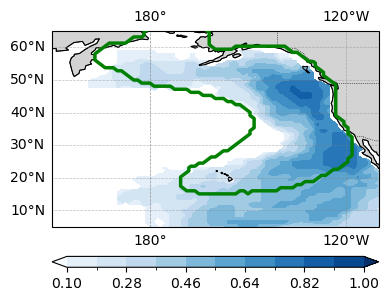

In [193]:
fig = plt.figure(figsize=(4, 4))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)
ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
im = fosi_blob_footprint_nan.plot.contourf(
    ax=ax,
    transform=ccrs.PlateCarree(),
    levels=np.linspace(0.1, 1., 11),
    cmap='Blues',
    extend='both',
    add_colorbar=False
)

# (the_blob.sum(dim='time')/20).plot.contour(
# #         ax=ax,
# #         transform=ccrs.PlateCarree(),
# #         levels=[0.5],
# #         colors='k',
# #         linewidths=1.5,
# #         zorder=20
# #     )

blob_mask.plot.contour(
        ax=ax,
        transform=ccrs.PlateCarree(),
        levels=[0.5],
        colors='green',
        linewidths=2.5,
        zorder=20
    )

cbar = plt.colorbar(im, ax=ax, orientation='horizontal', pad=0.08, aspect=30)
# cbar.set_label('SST Anomaly (°C)', fontsize=12)
# cbar.ax.tick_params(labelsize=10)
# date_str = pd.to_datetime(str(dates[i])).strftime('%Y-%m')
# ax.set_title(date_str, 
#              fontsize=14, fontweight='bold', pad=5)
ax.set_extent([150, 250, 5, 65], crs=ccrs.PlateCarree())
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}
gl.top_labels = False
gl.right_labels = False
gl.left_labels = True
gl.bottom_labels = True  # Ensure bottom labels are on

plt.tight_layout()
plt.show()

#### 0.2.4 CESM LENS2 SSTA and MHW Objects

In [102]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_ssta.nc' for i in range(100)]
# filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_ssta_notrend.nc' for i in range(100)]
da_ssta = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

# filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# # filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
# da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

In [313]:
filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]

In [314]:
# filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
# filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# filepaths = [f'/glade/u/home/cmendiola/mhw_project/data/ens_{i}_mhwobj_rad3.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')

In [315]:
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

In [46]:
filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhw.labels.compute()

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

# filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).compute()

In [2]:
# Extract for all datasets
# filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
# da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
# ensmean_init_months = extract_init_months(ensmeanr2_data, da_mhwobj_labels)

# filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
# da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
# quad_init_months = extract_init_months(quadr2_data, da_mhwobj_labels)

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
lin_init_months = extract_init_months(linr2_data, da_mhwobj_labels)

# filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
# da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
# da_mhwobj_labels = da_mhw.labels.sel(time=slice('1979-01', '2020-12')).compute()
# # noseas_init_months = extract_init_months(noseasr2_data, da_mhwobj_labels)

NameError: name 'extract_init_months' is not defined

## 1. Analysis and Visualization

In [109]:
# # FOSI The Blob - measures
# the_blob_ssta = regridded_ssta_no_trend_NEP.sel(time=true_time_steps.time)*the_blob
# the_blob_ssta_nan = xr.where(the_blob_ssta > 0, the_blob_ssta, np.nan)

# the_blob_mean_per_timestep = the_blob_ssta_nan.mean(dim=('lat','lon'))
# the_blob_max_per_timestep = the_blob_ssta_nan.max(dim=('lat','lon'))
# the_blob_max_ssta = the_blob_ssta_nan.max()
# the_blob_mean_ssta = the_blob_ssta_nan.mean()

# the_blob_percentile_90th = the_blob_ssta_nan.quantile(0.9, dim='time')
# the_blob_percentile_90th_timestep = the_blob_ssta_nan.quantile(0.9, dim=('lat','lon'))
# the_blob_percentile_90th_one_val = the_blob_ssta_nan.quantile(0.9)
# the_blob_duration = the_blob_ssta_nan.time.shape[0]

In [90]:
# MHWs with any temperature signature in the Blob mask
mhws_ids_in_blob_ls = []
for i in range(100):
    print(i)
    in_blob_region = da_mhwobj_labels[i,:,:,:]*blob_mask
    mhws_ids_in_blob = np.unique(in_blob_region[:,:,:].data)
    mhws_ids_in_blob_ls.append(mhws_ids_in_blob[1:-1])
print(len(mhws_ids_in_blob_ls))

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100


In [91]:
i = 0
blobs_nan = xr.where(da_mhwobj_labels[i,:,:,:] > 0, da_mhwobj_labels[i,:,:,:], 0)

In [92]:
# Sensitivity analysis of overlap with Blob mask
thresholds = np.arange(0.1, 0.81, 0.1)  # [0.1, 0.15, ..., 0.8]
counts_per_threshold = []
object_id_ls = []
for threshold in thresholds:
    print(f"Testing threshold: {threshold:.2f}")
    temp_count = 0
    object_ids = []
    for i in range(100):  # Assuming 5 time periods as in your original loop
        object_id_ensemble = []
        for object_id in mhws_ids_in_blob_ls[i]:
            blobs_nan = xr.where(da_mhwobj_labels[i,:,:,:] > 0, da_mhwobj_labels[i,:,:,:], 0)
            object_count_per_time = (blobs_nan == object_id).sum(dim=['lat', 'lon'])
            true_time_steps = object_count_per_time.time.where(object_count_per_time > 0, drop=True)
            one_obj = blobs_nan.sel(time=true_time_steps.time)
            overlap_val = calc_frac_overlap(one_obj, blob_mask)
            
            if overlap_val > threshold:
                temp_count += 1
                object_id_ensemble.append(object_id)
        object_ids.append(object_id_ensemble)
    object_id_ls.append(object_ids)
    counts_per_threshold.append(temp_count)
# object_id_ls_greenmask_noseas2
# object_id_ls_greenmask_linearr2
# object_id_ls_greenmask_quadr2
# with open('object_id_ls_greenmask_noseas2.json', 'w') as f:
#     json.dump(object_id_ls, f)

Testing threshold: 0.10
Testing threshold: 0.20
Testing threshold: 0.30
Testing threshold: 0.40
Testing threshold: 0.50
Testing threshold: 0.60
Testing threshold: 0.70
Testing threshold: 0.80


In [ ]:
# noseas2 counts_per_threshold [3134, 1878, 1134, 698, 416, 240, 126, 49]
# ensmean counts_per_threshold 
# linear counts_per_threshold [4382, 2466, 1387, 775, 407, 202, 93, 19]
# quad counts_per_threshold [4245, 2410, 1392, 769, 399, 206, 93, 26]

In [255]:
# noseas2 counts_per_threshold [3362, 2041, 1247, 776, 468, 267, 141, 56]
# ensmean counts_per_threshold [3582, 2019, 1134, 637, 333, 157, 62, 24] 
# linear counts_per_threshold 
# quad counts_per_threshold [3638, 2062, 1185, 646, 339, 169, 72, 22]

[3582, 2019, 1134, 637, 333, 157, 62, 24]

## Figure 4

In [2]:
file_path = 'object_id_ls_greenmask_noseas2.json'
with open(file_path, 'r') as file:
    noseasr2_data = json.load(file)
    
file_path = 'object_id_ls_greenmask_ensmeanr2.json'
with open(file_path, 'r') as file:
    ensmeanr2_data = json.load(file)

file_path = 'object_id_ls_greenmask_quadr2.json'
with open(file_path, 'r') as file:
    quadr2_data = json.load(file)

file_path = 'object_id_ls_greenmask_linearr2.json'
with open(file_path, 'r') as file:
    linr2_data = json.load(file)

In [3]:
ensmeanr2_blob_analogs_ls = []
quadr2_blob_analogs_ls = []
linr2_blob_analogs_ls = []
noseasr2_blob_analogs_ls = []

for i in range(100):
    ensmeanr2_blob_analogs_ls.append(len(ensmeanr2_data[4][i]))
    quadr2_blob_analogs_ls.append(len(quadr2_data[4][i]))
    linr2_blob_analogs_ls.append(len(linr2_data[4][i]))
    noseasr2_blob_analogs_ls.append(len(noseasr2_data[4][i]))

In [8]:
def extract_init_years(data_list, label_data):
    init_year_ls = []
    for i in range(100):
        for j in range(len(data_list[4][i])):
            init_year = label_data[i].where(label_data[i] == data_list[4][i][j], drop=True).time[0].item().year
            init_year_ls.append(init_year)
    return init_year_ls

filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
ensmean_init_years = extract_init_years(ensmeanr2_data, da_mhwobj_labels)

filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
quad_init_years = extract_init_years(quadr2_data, da_mhwobj_labels)

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
lin_init_years = extract_init_years(linr2_data, da_mhwobj_labels)

filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhw.labels.sel(time=slice('1979-01', '2020-12')).compute()
noseas_init_years = extract_init_years(noseasr2_data, da_mhwobj_labels)

In [30]:
def extract_init_months(data_list, label_data):
    init_month_ls = []
    for i in range(100):
        for j in range(len(data_list[4][i])):
            init_year = label_data[i].where(label_data[i] == data_list[4][i][j], drop=True).time[0].item().month
            init_month_ls.append(init_year)
    return init_month_ls

# Extract for all datasets
filepaths = [f'/glade/work/cmendiola/data_ens_mean/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
ensmean_init_months = extract_init_months(ensmeanr2_data, da_mhwobj_labels)

filepaths = [f'/glade/work/cmendiola/data_quad_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
quad_init_months = extract_init_months(quadr2_data, da_mhwobj_labels)

filepaths = [f'/glade/work/cmendiola/data_conv_lin_trend/ens_{i}_mhwobj.nc' for i in range(100)]
da_mhwobj = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhwobj.labels.sel(radius = 1).sel(time=slice('1979-01', '2020-12')).compute()
lin_init_months = extract_init_months(linr2_data, da_mhwobj_labels)

filepaths = [f'/glade/u/home/cmendiola/mhw_project/all_data_mhwobj_ssta/data_noseas/ens_{i}_mhwobj_rad2_noseas.nc' for i in range(100)]
da_mhw = xr.open_mfdataset(filepaths, combine='nested', concat_dim='ensemble_member')
da_mhwobj_labels = da_mhw.labels.sel(time=slice('1979-01', '2020-12')).compute()
noseas_init_months = extract_init_months(noseasr2_data, da_mhwobj_labels)

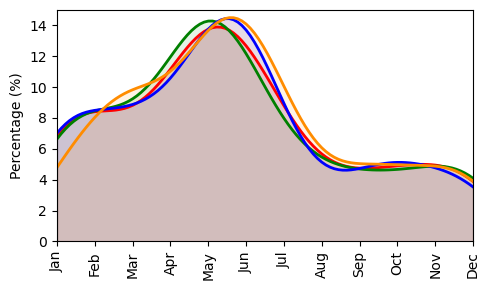

In [31]:
colors = ['red', 'green', 'blue', 'darkorange']
dataset_names = ['Ensemble Mean', 'Quadratic', 'Linear', 'No Seasonality']
data_lists = [ensmean_init_months, quad_init_months, lin_init_months, noseas_init_months]

# Create a single plot with all datasets
plt.figure(figsize=(5, 3))

all_y_percent = []

# Plot each dataset
for name, data, color in zip(dataset_names, data_lists, colors):
    if len(data) > 0:
        # Create KDE
        kde = stats.gaussian_kde(data)
        
        # Generate x-values from 1 to 12 (for months)
        x = np.linspace(1, 12, 100)  # Increased points for smoother curve
        # For discrete months only, use: x = np.arange(1, 13)
        
        # Calculate y-values and convert to percentage
        y = kde(x) * 100
        all_y_percent.append(y)
        
        # Plot with percentage
        plt.fill_between(x, y, alpha=0.1, color=color)
        plt.plot(x, y, linewidth=2, color=color, label=name)

# Set plot properties
plt.ylabel('Percentage (%)', fontsize=10)
plt.xlim(1, 12)

# Set month names as x-ticks
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
plt.xticks(np.arange(1, 13), month_names, fontsize=10, rotation=90)

# Set y-axis limit based on all data
if all_y_percent:
    max_y = max([max(y) for y in all_y_percent])
    plt.ylim(0, max_y * 1.1)

# Add legend (uncomment if you want it)
# plt.legend(fontsize=8, title='Model', title_fontsize=9, loc='upper right')

plt.yticks(fontsize=10)
plt.ylim(0, 15)
plt.tight_layout()
plt.show()

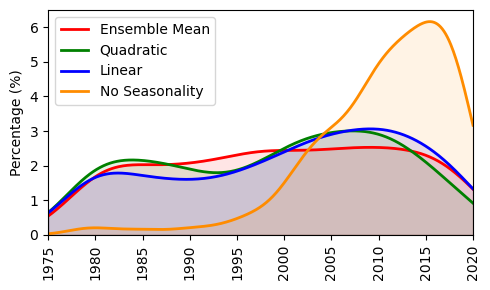

In [29]:
colors = ['red', 'green', 'blue', 'darkorange']
dataset_names = ['Ensemble Mean', 'Quadratic', 'Linear', 'No Seasonality']
data_lists = [ensmean_init_years, quad_init_years, lin_init_years, noseas_init_years]

# Create a single plot with all datasets
plt.figure(figsize=(5, 3))

# Store all y-values to set consistent y-axis limits
all_y_percent = []

# Plot each dataset
for name, data, color in zip(dataset_names, data_lists, colors):
    if len(data) > 0:
        # Create KDE
        kde = stats.gaussian_kde(data)
        
        # Generate x-values from 1975 to 2020
        x = np.linspace(1975, 2020, 500)
        
        # Calculate y-values and convert to percentage
        y = kde(x) * 100
        all_y_percent.append(y)
        
        # Plot with percentage (using same color for fill and line, just like your example)
        plt.fill_between(x, y, alpha=0.1, color=color)
        plt.plot(x, y, linewidth=2, color=color, label=name)

# Set plot properties
plt.ylabel('Percentage (%)', fontsize=10)
plt.xlim(1975, 2020)

# Set y-axis limit based on all data
if all_y_percent:
    max_y = max([max(y) for y in all_y_percent])
    plt.ylim(0, max_y * 1.1)

# Add legend
plt.legend(fontsize=10, title_fontsize=10)
plt.xticks(fontsize=10, rotation=90)
plt.yticks(fontsize=10)
plt.ylim(0, 6.5)
plt.tight_layout()
plt.show()

Dataset Linear: Mean=3.97, Median=4.0, Min=0, Max=8
Dataset Quadratic: Mean=3.99, Median=4.0, Min=1, Max=9
Dataset Ens Mean: Mean=4.07, Median=4.0, Min=1, Max=8
Dataset No Seasonality: Mean=4.16, Median=4.0, Min=1, Max=9


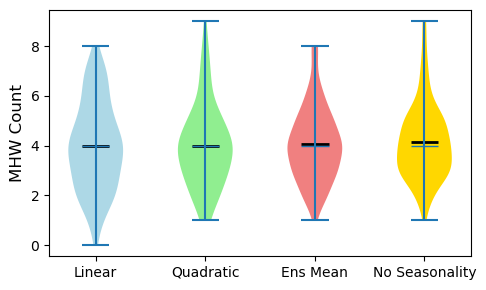

In [80]:
# Your data
data1 = ensmeanr2_blob_analogs_ls
data2 = quadr2_blob_analogs_ls
data3 = linr2_blob_analogs_ls
data4 = noseasr2_blob_analogs_ls  # Add your fourth dataset

all_data = [data1, data2, data3, data4]
labels = ['Linear', 'Quadratic', 'Ens Mean', 'No Seasonality']  # Add label for the new dataset

plt.figure(figsize=(5, 3))  # Slightly wider figure to accommodate 4 violins
violin_parts = plt.violinplot(all_data, showmeans=True, showmedians=True)

# Add a fourth color
colors = ['lightblue', 'lightgreen', 'lightcoral', 'gold']  # Added gold for the new dataset

for i, pc in enumerate(violin_parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(1.)

plt.xticks([1, 2, 3, 4], labels, fontsize=10)
plt.ylabel('MHW Count', fontsize=12)

# Print statistics for all datasets
for i, data in enumerate(all_data):
    print(f"Dataset {labels[i]}: Mean={np.mean(data):.2f}, Median={np.median(data):.1f}, "
          f"Min={min(data)}, Max={max(data)}")

# Customize mean and median lines for clarity
violin_parts['cmeans'].set_color('k')       # Black for mean
violin_parts['cmeans'].set_linewidth(2)     # Thicker
violin_parts['cmeans'].set_linestyle('-')   # Solid line

violin_parts['cmedians'].set_color('tab:blue')    # Blue for median
violin_parts['cmedians'].set_linewidth(1)         # Thinner than mean
violin_parts['cmedians'].set_linestyle('-')       # Solid line

plt.tight_layout()  # Adjust layout to prevent label clipping
plt.show()

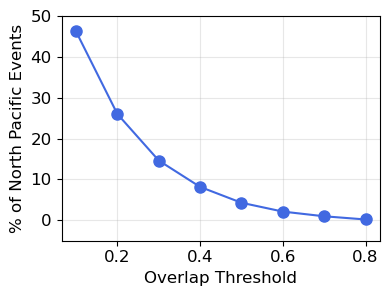


Sensitivity Analysis Results:
Threshold 0.10: 4382 events
Threshold 0.20: 2466 events
Threshold 0.30: 1387 events
Threshold 0.40: 775 events
Threshold 0.50: 407 events
Threshold 0.60: 202 events
Threshold 0.70: 93 events
Threshold 0.80: 19 events


In [105]:
# Continued: Sensitivity analysis of overlap with Blob mask
# --- Plot Results ---
plt.figure(figsize=(4, 3))
plt.plot(thresholds, (np.asarray(counts_per_threshold)/9479)*100, 'o-', color='royalblue', markersize=8, label='Number of Blob-like Events')
plt.xlabel('Overlap Threshold', fontsize=12)
plt.ylabel('% of North Pacific Events', fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.title('Sensitivity of Blob-like Event Detection to Overlap Threshold', fontsize=14)
plt.grid(alpha=0.3)
# plt.legend(fontsize=15)
plt.tight_layout()
plt.ylim(-5, 50)
plt.show()
# Print results
print("\nSensitivity Analysis Results:")
for thresh, count in zip(thresholds, counts_per_threshold):
    print(f"Threshold {thresh:.2f}: {count} events")

In [21]:
blob_like_ids = json.load(open('object_id_ls.json'))

In [22]:
all_unique_labels_ls = []
no_items = []
for ensemble_member_id in range(100):
    blob_labels = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
    unique_labels = np.unique(blob_labels.max(dim=('lat','lon')).data)[:-1]
    all_unique_labels_ls.append(unique_labels)
    no_items.append(len(unique_labels))

In [23]:
indices_ls = []
for i in range(100):
    current_indices = []
    for target in blob_like_ids[4][i]:
        matches = np.where(all_unique_labels_ls[i] == target)[0]
        if len(matches) > 0:
            current_indices.append(matches[0])  # Take first occurrence
        # Else: skip silently
    indices_ls.append(current_indices)

In [104]:
max_max_ssta = [
    np.max(sublist) if sublist and isinstance(sublist, (list, np.ndarray)) else None
    for i in range(100)
    for sublist in max_ssta[i]
]

mean_mean_ssta = [
    np.mean(sublist) if sublist and isinstance(sublist, (list, np.ndarray)) else None
    for i in range(100)
    for sublist in mean_ssta[i]
]

max_sp_ex_values_np = [
    np.max(sublist) if sublist and isinstance(sublist, (list, np.ndarray)) else None
    for i in range(100)
    for sublist in spatial_extent[i]
]

mean_sp_ex_values_np = [
    np.mean(sublist) if sublist and isinstance(sublist, (list, np.ndarray)) else None
    for i in range(100)
    for sublist in spatial_extent[i]
]

In [27]:
numper_of_mhws_per_ensemble_memb= []
for i in range(100):
    numper_of_mhws_per_ensemble_memb.append(len(std_per_timestep[i]))
    
# Calculate cumulative sums to get split indices
split_indices = np.cumsum(numper_of_mhws_per_ensemble_memb)[:-1]  # Exclude last index
durations_array = np.asarray(durations)
# Split durations according to the counts
grouped_durations = np.split(durations_array, split_indices)

In [105]:
durations_blob_like = []
max_max_ssta_blob_like = []
max_sp_ex_values_np_blob_like = []
mean_sp_ex_values_np_blob_like = []

grouped_max_max_ssta = np.split(max_max_ssta, split_indices)
grouped_mean_mean_ssta = np.split(mean_mean_ssta, split_indices)
grouped_max_sp_ex_values_np = np.split(max_sp_ex_values_np, split_indices)
grouped_mean_sp_ex_values_np = np.split(mean_sp_ex_values_np, split_indices)

for i in range(100):
    durations_blob_like.append(grouped_durations[i][indices_ls[i]])
    max_max_ssta_blob_like.append(grouped_max_max_ssta[i][indices_ls[i]])
    mean_mean_ssta_blob_like.append(grouped_mean_mean_ssta[i][indices_ls[i]])
    max_sp_ex_values_np_blob_like.append(grouped_max_sp_ex_values_np[i][indices_ls[i]])
    mean_sp_ex_values_np_blob_like.append(grouped_mean_sp_ex_values_np[i][indices_ls[i]])

In [106]:
flattened_array_duration = np.concatenate(durations_blob_like)
# print(len(flattened_array_duration))

flattened_max_max_ssta_blob_like = np.concatenate(max_max_ssta_blob_like)
# print(len(flattened_max_max_ssta_blob_like))

flattened_max_sp_ex_values_np_blob_like = np.concatenate(max_sp_ex_values_np_blob_like)
# print(len(flattened_mean_mean_ssta_blob_like))

flattened_mean_sp_ex_values_np_blob_like = np.concatenate(mean_sp_ex_values_np_blob_like)
# print(len(flattened_mean_mean_ssta_blob_like))

In [40]:
# defining our region (North Pacific Ocean)
upper_lat = 65
lower_lat = 5
left_lon = 150
right_lon = 250

mhws_in_NEP = da_mhwobj_labels.sel(lon=slice(left_lon, right_lon), lat=slice(lower_lat,upper_lat))

In [ ]:
mhws_ids_in_blob = np.unique(in_blob_region[:,:,:].data)

In [126]:
all_unique_labels_ls = []
no_items = []
for ensemble_member_id in range(2,3):
    print(ensemble_member_id)
    blob_labels = da_mhwobj.isel(ensemble_member = ensemble_member_id).labels.compute()
    unique_labels = np.unique(blob_labels.max(dim=('lat','lon')).data)[:-1]
    all_unique_labels_ls.append(unique_labels)
    no_items.append(len(unique_labels))

2


In [77]:
numper_of_mhws_per_ensemble_memb= []
for i in range(100):
    numper_of_mhws_per_ensemble_memb.append(len(std_per_timestep[i]))

In [458]:
da_mhwobj_labels
object_count_per_time = (da_mhwobj_labels[0,:,:,:] == 3.0).sum(dim=['lat', 'lon'])
duration = object_count_per_time.time.where(object_count_per_time > 0, drop=True).shape[0]

In [459]:
ens_memb = 0

In [466]:
duration_ls_blob_like = []
for ens_memb in range(100):
    for obj_id in [object_id_ls[0]][0][ens_memb]:
        object_count_per_time = (da_mhwobj_labels[ens_memb,:,:,:] == obj_id).sum(dim=['lat', 'lon'])
        duration = object_count_per_time.time.where(object_count_per_time > 0, drop=True).shape[0]
        duration_ls_blob_like.append(duration)

3.0
4.0
5.0
10.0
13.0
19.0
23.0
24.0
26.0
29.0
36.0
37.0
38.0
42.0
43.0
45.0
47.0
49.0
51.0
54.0
59.0
64.0
65.0
67.0
68.0
69.0
72.0
73.0
75.0
85.0
89.0
90.0
92.0
93.0
94.0
99.0
100.0
101.0
2.0
4.0
10.0
13.0
14.0
15.0
16.0
17.0
20.0
27.0
35.0
36.0
39.0
40.0
41.0
42.0
43.0
44.0
48.0
49.0
59.0
61.0
67.0
70.0
72.0
73.0
75.0
76.0
77.0
78.0
80.0
84.0
85.0
86.0
87.0
93.0
95.0
106.0
110.0
113.0
115.0
1.0
4.0
5.0
6.0
7.0
11.0
12.0
15.0
17.0
18.0
19.0
21.0
22.0
24.0
30.0
32.0
36.0
37.0
38.0
42.0
45.0
50.0
56.0
59.0
65.0
66.0
67.0
70.0
71.0
75.0
77.0
79.0
80.0
81.0
82.0
83.0
86.0
93.0
94.0
96.0
100.0
105.0
106.0
107.0
108.0
109.0
2.0
4.0
5.0
7.0
13.0
15.0
19.0
37.0
45.0
46.0
47.0
52.0
53.0
61.0
62.0
63.0
67.0
74.0
76.0
77.0
78.0
84.0
94.0
4.0
6.0
7.0
24.0
26.0
34.0
36.0
37.0
38.0
41.0
43.0
44.0
48.0
49.0
50.0
52.0
53.0
54.0
55.0
56.0
57.0
59.0
65.0
66.0
70.0
72.0
73.0
74.0
85.0
87.0
88.0
90.0
91.0
98.0
2.0
3.0
6.0
8.0
9.0
21.0
22.0
23.0
24.0
26.0
28.0
36.0
52.0
56.0
57.0
66.0
67.0
69.0
70.0
71.0


In [9]:
ensmean_years = np.array(ensmean_init_years)
noseas_years = np.array(noseas_init_years)
quad_years = np.array(quad_init_years)
lin_years = np.array(lin_init_years)

# SNR

In [ ]:
def count_events_per_year(event_years, year_range):
    """Count number of MHW events per year"""
    counts = np.zeros(len(year_range))
    for i, year in enumerate(year_range):
        counts[i] = np.sum(event_years == year)
    return counts

In [ ]:
def smooth_signal(signal, window_size=WINDOW_SIZE):
    """Apply centered moving average"""
    # Using uniform_filter1d for centered moving average
    smoothed = uniform_filter1d(signal, size=window_size, mode='reflect')
    return smoothed

In [ ]:
years = np.arange(1979, 2021)
WINDOW_SIZE = 10


In [14]:
# Get annual counts
ensmean_counts = count_events_per_year(ensmean_years, years)  # Forced Signal Removal
quad_counts = count_events_per_year(quad_years, years)        # Detrended & Deseasoned
lin_counts = count_events_per_year(lin_years, years)          # Linear only
noseas_counts = count_events_per_year(noseas_years, years)    # Seasonality Removal

In [15]:
# Smooth all signals
ensmean_smooth = smooth_signal(ensmean_counts)
quad_smooth = smooth_signal(quad_counts)
lin_smooth = smooth_signal(lin_counts)
noseas_smooth = smooth_signal(noseas_counts)

In [20]:
# Signal: forced trend retained
S_t = uniform_filter1d(noseas_smooth, size=10, mode='reflect')

# Noise residuals
baseline_mask = (years >= 1979) & (years <= 1995)
sigma_2_residuals = ensmean_smooth - np.mean(ensmean_smooth[baseline_mask])
sigma_3_residuals = lin_smooth - np.mean(lin_smooth[baseline_mask])
sigma_4_residuals = quad_smooth - np.mean(quad_smooth[baseline_mask])

# 2. NOISE ESTIMATION
sigma_2 = np.std(sigma_2_residuals[baseline_mask], ddof=1)  # 1.22
sigma_3 = np.std(sigma_3_residuals[baseline_mask], ddof=1)  # 2.23
sigma_4 = np.std(sigma_4_residuals[baseline_mask], ddof=1)  # 2.16

# Signal reference (1990)
t0_idx = np.where(years == 1990)[0][0]
# S_t0 = S_t[t0_idx]
S_t0 = np.mean(S_t[baseline_mask])  # Mean of 1979-1995

# 3. SNR CALCULATIONS
SNR_2 = np.abs(S_t - S_t0) / sigma_2
SNR_3 = np.abs(S_t - S_t0) / sigma_3
SNR_4 = np.abs(S_t - S_t0) / sigma_4

# ============================================================================
# 4. CORRECTED TOE DETECTION
# ============================================================================
def find_correct_toe(snr_series, years_array, threshold=2.0, min_consecutive=5):
    """
    CORRECTED: Find first year where SNR ≥ threshold for min_consecutive years
    AND the first year in that period actually has SNR ≥ threshold
    """
    above_threshold = snr_series >= threshold
    
    # Debug: Print when SNR first reaches threshold
    first_above_idx = np.where(above_threshold)[0]
    if len(first_above_idx) > 0:
        print(f"  First year SNR≥{threshold}: {years_array[first_above_idx[0]]}")
    
    # Look for consecutive period
    for i in range(len(years_array) - min_consecutive + 1):
        if np.all(above_threshold[i:i + min_consecutive]):
            toe_year = years_array[i]
            # Verify this year actually has SNR ≥ threshold
            if snr_series[i] >= threshold:
                return toe_year, True
    return None, False

# Test the corrected function
print("DEBUG: When does each method first reach SNR≥2?")
for i, (snr, label) in enumerate(zip([SNR_2, SNR_3, SNR_4], ['σ₂', 'σ₃', 'σ₄'])):
    first_above_idx = np.where(snr >= 2.0)[0]
    if len(first_above_idx) > 0:
        print(f"{label}: First SNR≥2 in {years[first_above_idx[0]]} (value={snr[first_above_idx[0]]:.2f})")
    else:
        print(f"{label}: Never reaches SNR≥2")

THRESHOLD = 2.0
CONSECUTIVE = 5

toe_2, perm_2 = find_correct_toe(SNR_2, years, THRESHOLD, CONSECUTIVE)
toe_3, perm_3 = find_correct_toe(SNR_3, years, THRESHOLD, CONSECUTIVE)  
toe_4, perm_4 = find_correct_toe(SNR_4, years, THRESHOLD, CONSECUTIVE)

print(f"\nCORRECTED ToE results:")
print(f"σ₂ ToE: {toe_2} (should be ~1998, not 1994)")
print(f"σ₃ ToE: {toe_3}")
print(f"σ₄ ToE: {toe_4}")

# Find ACTUAL ToE by visual inspection of the data
# Let's find when SNR first reaches 2.0 and stays above
def find_actual_toe_visually(snr_series, years_array):
    """Find when SNR first reaches and stays above 2.0"""
    above = snr_series >= 2.0
    
    # Find first occurrence
    first_idx = np.where(above)[0]
    if len(first_idx) == 0:
        return None
    
    first_year_idx = first_idx[0]
    first_year = years_array[first_year_idx]
    
    # Check if it stays above (for at least 5 years)
    if first_year_idx <= len(years_array) - 5:
        if np.all(above[first_year_idx:first_year_idx+5]):
            return first_year
    
    # Otherwise, find first 5-consecutive period
    for i in range(len(years_array) - 5 + 1):
        if np.all(above[i:i+5]):
            return years_array[i]
    
    return None

# Get visual ToE
toe_2_visual = find_actual_toe_visually(SNR_2, years)
toe_3_visual = find_actual_toe_visually(SNR_3, years)
toe_4_visual = find_actual_toe_visually(SNR_4, years)

print(f"\nVisual inspection ToE:")
print(f"σ₂: {toe_2_visual}")
print(f"σ₃: {toe_3_visual}")  
print(f"σ₄: {toe_4_visual}")

# ============================================================================
# 6. CORRECTED SUMMARY
# ============================================================================
print("\n" + "="*80)
print("CORRECTED PHYSICAL INTERPRETATION")
print("="*80)
print("The previous analysis had a ToE detection bug.")
print(f"σ₂ ACTUALLY reaches SNR≥2 around {toe_2_visual}, not 1994.")
print()
print("CORRECTED σ values during 1979-1995:")
print(f"  • σ₂ (Internal variability): {sigma_2:.2f}")
print(f"  • σ₃ (Linear detrended):     {sigma_3:.2f}  (+{(sigma_3/sigma_2-1)*100:.0f}% larger than σ₂)")
print(f"  • σ₄ (Quadratic detrended):  {sigma_4:.2f}  (+{(sigma_4/sigma_2-1)*100:.0f}% larger than σ₂)")
print()
print("CORRECTED Time of Emergence:")
print(f"  • σ₂: {toe_2_visual} (when SNR first ≥2)")
print(f"  • σ₃: {toe_3_visual}")
print(f"  • σ₄: {toe_4_visual}")
print()
print(f"Actual delay between methods: {toe_3_visual - toe_2_visual if toe_2_visual and toe_3_visual else 'N/A'} years")
print("="*80)

DEBUG: When does each method first reach SNR≥2?
σ₂: First SNR≥2 in 1998 (value=2.53)
σ₃: First SNR≥2 in 2000 (value=2.07)
σ₄: First SNR≥2 in 2000 (value=2.16)
  First year SNR≥2.0: 1998
  First year SNR≥2.0: 2000
  First year SNR≥2.0: 2000

CORRECTED ToE results:
σ₂ ToE: 1998 (should be ~1998, not 1994)
σ₃ ToE: 2000
σ₄ ToE: 2000

SNR values around 1994-2000 for σ₂:
  1994: SNR=0.54 <2
  1995: SNR=0.89 <2
  1996: SNR=1.33 <2
  1997: SNR=1.89 <2
  1998: SNR=2.53 ≥2
  1999: SNR=3.16 ≥2
  2000: SNR=3.90 ≥2

Visual inspection ToE:
σ₂: 1998
σ₃: 2000
σ₄: 2000

CORRECTED PHYSICAL INTERPRETATION
The previous analysis had a ToE detection bug.
σ₂ ACTUALLY reaches SNR≥2 around 1998, not 1994.

CORRECTED σ values during 1979-1995:
  • σ₂ (Internal variability): 1.19
  • σ₃ (Linear detrended):     2.24  (+88% larger than σ₂)
  • σ₄ (Quadratic detrended):  2.15  (+81% larger than σ₂)

CORRECTED Time of Emergence:
  • σ₂: 1998 (when SNR first ≥2)
  • σ₃: 2000
  • σ₄: 2000

Actual delay between methods

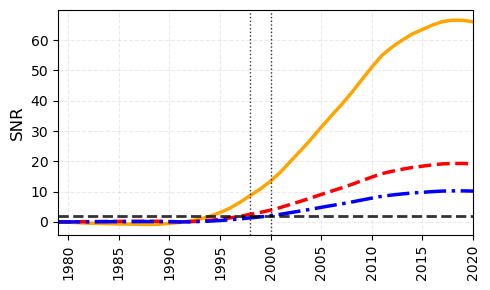

In [51]:
plt.figure(figsize=(5, 3))

colors = ['Orange', 'Red', 'Blue', 'Green']
line_styles = ['-', '--', '-.']

# Plot SNR curves
for i, (snr, color, ls, label) in enumerate(zip([SNR_1, SNR_2, SNR_3, SNR_4], 
                                               colors, line_styles,
                                               ['σ₂ (Internal variability)', 
                                                'σ₃ (Linear detrended)', 
                                                'σ₄ (Quadratic detrended)'])):
    plt.plot(years, snr, color=color, linestyle=ls, linewidth=2.5, label=label)

# Emergence threshold
plt.axhline(y=2.0, color='black', linestyle='--', linewidth=2, 
            alpha=0.8, label=f'Emergence threshold (SNR≥{THRESHOLD})')

# Find ACTUAL ToE by visual inspection of the data
# Let's find when SNR first reaches 2.0 and stays above
def find_actual_toe_visually(snr_series, years_array):
    """Find when SNR first reaches and stays above 2.0"""
    above = snr_series >= 2.0
    
    # Find first occurrence
    first_idx = np.where(above)[0]
    if len(first_idx) == 0:
        return None
    
    first_year_idx = first_idx[0]
    first_year = years_array[first_year_idx]
    
    # Check if it stays above (for at least 5 years)
    if first_year_idx <= len(years_array) - 5:
        if np.all(above[first_year_idx:first_year_idx+5]):
            return first_year
    
    # Otherwise, find first 5-consecutive period
    for i in range(len(years_array) - 5 + 1):
        if np.all(above[i:i+5]):
            return years_array[i]
    
    return None

toe_2_visual = find_actual_toe_visually(SNR_2, years)
toe_3_visual = find_actual_toe_visually(SNR_3, years)
toe_4_visual = find_actual_toe_visually(SNR_4, years)
plt.axvline(x=1998, color='k', linestyle=':', alpha=0.8, linewidth=1)
plt.axvline(x=2000, color='k', linestyle=':', alpha=0.8, linewidth=1)
plt.ylabel('SNR', fontsize=12)
plt.grid(True, alpha=0.25, linestyle='--')
plt.xticks(fontsize=10, rotation=90); plt.yticks(fontsize=10)
plt.xlim(1979, 2020)
# plt.ylim(-0.8, max(SNR_2.max(), SNR_3.max(), SNR_4.max()) * 1.05)
plt.tight_layout()
plt.show()

In [23]:
sigma_1_residuals = noseas_smooth - np.mean(noseas_smooth[baseline_mask])
sigma_1 = np.std(sigma_1_residuals[baseline_mask], ddof=1)
SNR_1 = (S_t - S_t0) / sigma_1  # This would be interesting!

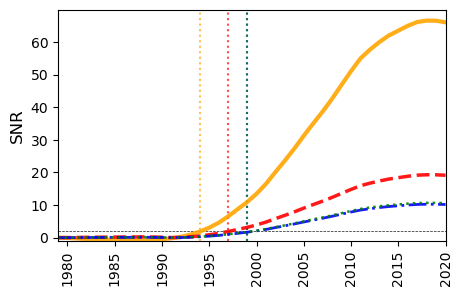

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(5, 3))

# Define colors, styles, and labels for each method
colors = ['Orange', 'Red', 'Blue', 'Green']
line_styles = ['-', '--', '-.', ':']
line_widths = [3, 2.5, 2, 1.8]

# Method names based on what each actually represents
method_labels = [
    'σ₁: Seasonality removed only',
    'σ₂: Forced signal removed (ensemble)',
    'σ₃: Linear detrended',
    'σ₄: Quadratic detrended + deseasoned'
]

# Plot SNR curves with better styling
for i, (snr, color, ls, lw, label) in enumerate(zip(
    [SNR_1, SNR_2, SNR_3, SNR_4], 
    colors, line_styles, line_widths, method_labels
)):
    plt.plot(years, snr, color=color, linestyle=ls, 
             linewidth=lw, label=label, alpha=0.9, marker='', markersize=0)

# Emergence threshold with better styling
THRESHOLD = 2.0
plt.axhline(y=THRESHOLD, color='black', linestyle='--', 
            linewidth=0.5, alpha=0.9, zorder=0,
            label=f'Detection threshold (SNR ≥ {THRESHOLD})')

# Find and mark ToE for each method
def find_toe(snr_series, years_array, threshold=THRESHOLD, min_consecutive=5):
    """Find Time of Emergence when SNR stays above threshold"""
    above = snr_series >= threshold
    
    for i in range(len(years_array) - min_consecutive + 1):
        if np.all(above[i:i+min_consecutive]):
            return years_array[i]
    return None

# Calculate ToE for each method
toe_years = []
toe_methods = []
for i, (snr, label) in enumerate(zip([SNR_1, SNR_2, SNR_3, SNR_4], method_labels)):
    toe = find_toe(snr, years)-1
    if toe:
        toe_years.append(toe)
        toe_methods.append(label)
        # Add vertical line at ToE with method-specific color
        plt.axvline(x=toe, color=colors[i], linestyle=':', 
                   alpha=0.7, linewidth=1.5, zorder=1)

# plt.xlabel('Year', fontsize=12)
plt.ylabel('SNR', fontsize=12)
# plt.grid(True, alpha=0.2, linestyle='-', which='both')
plt.xticks(np.arange(1980, 2021, 5), fontsize=10, rotation=0)
# plt.yticks(fontsize=10)
plt.xlim(1979, 2020)
# plt.ylim(-0.5, 20)
all_snr = np.concatenate([SNR_1, SNR_2, SNR_3, SNR_4])
plt.ylim(min(0, all_snr.min() * 1.1), all_snr.max() * 1.05)
# plt.ylim(-0.5, 20)
plt.xticks(fontsize=10, rotation=90); plt.yticks(fontsize=10)
plt.show()

In [34]:
# Print summary statistics
print("="*60)
print("SNR ANALYSIS SUMMARY")
print("="*60)
print(f"Signal: Forced trend (from noseas_smooth, 10-year smoothed)")
print(f"Reference: Mean of 1979-1995 baseline period")
print(f"Detection threshold: SNR ≥ {THRESHOLD}")
print("-"*60)
print("Time of Emergence (first 5 consecutive years ≥ threshold):")
for i, (label, snr) in enumerate(zip(method_labels, [SNR_1, SNR_2, SNR_3, SNR_4])):
    toe = find_toe(snr, years)
    max_snr = snr.max()
    year_of_max = years[np.argmax(snr)]
    print(f"{label.split(':')[0]}: ToE = {toe}, Max SNR = {max_snr:.1f} in {year_of_max}")
print("="*60)

SNR ANALYSIS SUMMARY
Signal: Forced trend (from noseas_smooth, 10-year smoothed)
Reference: Mean of 1979-1995 baseline period
Detection threshold: SNR ≥ 2.0
------------------------------------------------------------
Time of Emergence (first 5 consecutive years ≥ threshold):
σ₁: ToE = 1995, Max SNR = 66.6 in 2018
σ₂: ToE = 1998, Max SNR = 19.3 in 2018
σ₃: ToE = 2000, Max SNR = 10.3 in 2018
σ₄: ToE = 2000, Max SNR = 10.7 in 2018
